# 01 · Quickstart: recover the law each window came from

Every window of data was produced by one of `K` unknown closed-form laws
$y = f_{z_w}(x) + \varepsilon$. The label $z_w$ is never observed. LR-DSR
recovers **the partition and the laws together**.

This notebook runs the whole method on three laws in about ten seconds, and
draws every picture `lrdsr.viz` offers:

1. simulate windows whose *geometry* barely separates the regimes,
2. look at them in data space and in **mechanism space**,
3. fit the hard alternating loop (`GroupedDCSR`) and the soft EM (`SoftLRDSR`),
4. read off the recovered laws, the cost matrix, the learning curves, the
   posteriors,
5. change the loss, including a **learned** one.

In [1]:
import sys, pathlib
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from lrdsr import viz
viz.style()
pd.set_option("display.precision", 4)
RES = ROOT / "results"

## 1 · Simulate

Three laws, one shared input distribution $x \sim U[-2.2, 2.2]$, 16 noisy
samples a window. The window-level features `Z` a clustering would see are drawn with a
large spread (`geometry_overlap=3`), so they carry little about the regime.
The truth `z` is kept **for scoring only**.

In [2]:
from experiments.functions.data import simulate_function_windows

X, y, Z, z, equations = simulate_function_windows(
    n_windows=240, window_len=16, noise_std=1.5, geometry_overlap=3.0, seed=11)
true_laws = [lambda x: 0.8 * x**2 + 1.5 * x + 0.5,
             lambda x: 2.5 * np.sin(2 * x) - 0.5,
             lambda x: 0.35 * x**3 - 1.2]
print(X.shape, y.shape, "windows x samples x inputs")
for k, e in enumerate(equations):
    print(f"regime {k}: y = {e}   ({np.sum(z == k)} windows)")

(240, 16, 1) (240, 16) windows x samples x inputs
regime 0: y = 0.8*x^2 + 1.5*x + 0.5   (85 windows)
regime 1: y = 2.5*sin(2*x) - 0.5   (73 windows)
regime 2: y = 0.35*x^3 - 1.2   (82 windows)


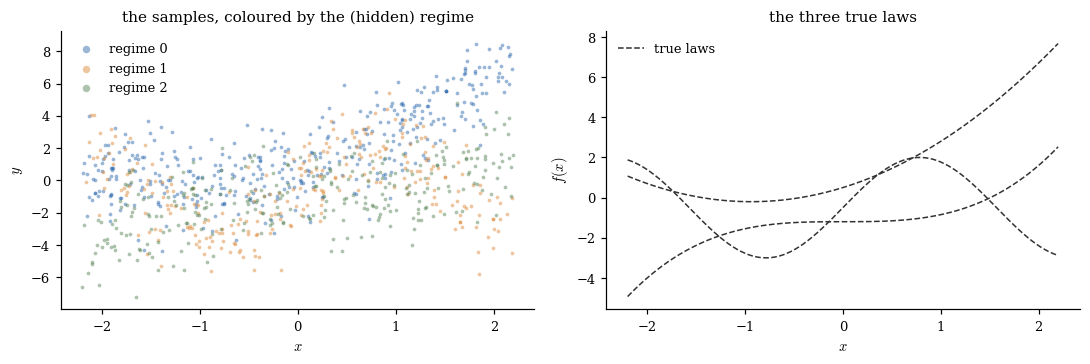

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
viz.plot_windows(X, y, z, ax=ax[0], max_windows=60)
ax[0].set_title("the samples, coloured by the (hidden) regime")
viz.plot_laws(truth=true_laws, x_range=(-2.2, 2.2), ax=ax[1])
ax[1].set_title("the three true laws")
fig.tight_layout()

## 2 · Data space against mechanism space

Left: two plain summaries of each window, what any clustering of windows
would see. Right: the same windows in **mechanism space** — whitened law
coefficients (`lrdsr.core.mechanism_space`). Distance there is distance
between *laws*, and the regimes separate.

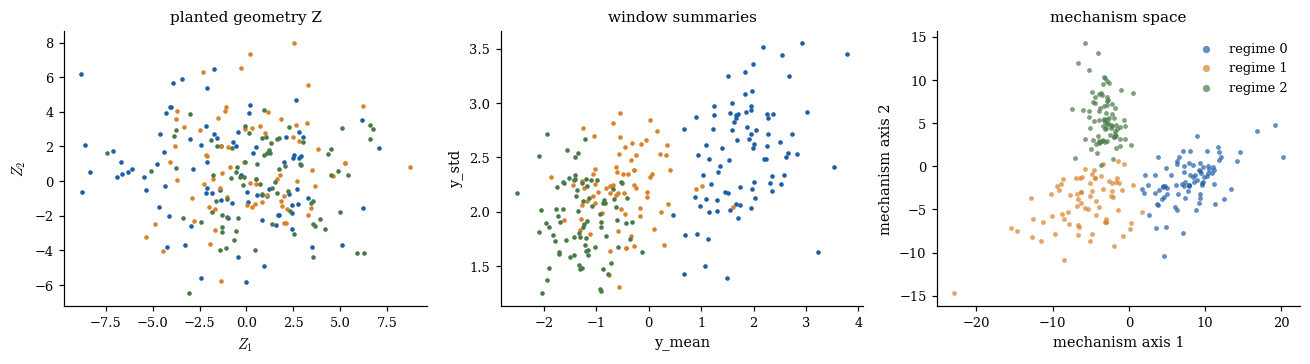

In [4]:
from experiments.common.fitting import window_features

Zf, names = window_features(X, y)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
for k in range(3):
    ax[0].scatter(Z[z == k, 0], Z[z == k, 1], s=9, color=viz.regime_color(k), lw=0)
    ax[1].scatter(Zf[z == k, 0], Zf[z == k, 1], s=9, color=viz.regime_color(k), lw=0)
ax[0].set(title="planted geometry Z", xlabel="$Z_1$", ylabel="$Z_2$")
ax[1].set(title="window summaries", xlabel=names[0], ylabel=names[1])
viz.plot_mechanism_space(X, y, z, ax=ax[2], feature_names=["x"])
fig.tight_layout()

## 3 · Fit the hard loop

`GroupedDCSR` initialises in mechanism space, fits a symbolic law per
cluster (greedy BIC over a fixed library), scores **every window under every
law** out-of-fold, reassigns, and repeats. `alpha_geom=0` makes assignment
purely mechanism-based. `true_labels_for_eval` only adds ARI to the history.

In [5]:
from lrdsr import GroupedDCSR
from lrdsr.core.evaluation import clustering_metrics

hard = GroupedDCSR(n_clusters=3, alpha_geom=0.0, init="mechanism", backend="fast",
                   backend_kwargs={"max_terms": 5}, score_mode="cross_fit",
                   residual_scale="global", random_state=11)
res = hard.fit(X, y, Z, feature_names=["x"], true_labels_for_eval=z)
print(clustering_metrics(z, res.labels))
for k, m in enumerate(res.models):
    print(f"law {k}: {m.expression()}")

{'ARI': 1.0, 'NMI': 1.0, 'aligned_accuracy': 1.0}
law 0: 2.7175 +1.4884*x -2.2863*cos(x)
law 1: -1.2222 +0.33956*(x)^3
law 2: -0.48016 +2.5939*sin(2*x)


Read the expressions against the truth before trusting them. With 16 samples
a window at this noise, a law can come back as a **predictively equivalent**
surrogate rather than in its own symbols -- e.g. a quadratic as
$a + b\,x + c\cos x$, since $\cos x \approx 1 - x^2/2$ on this range. The
partition is exact either way; the plot below is the check that the curves
agree where the data live.

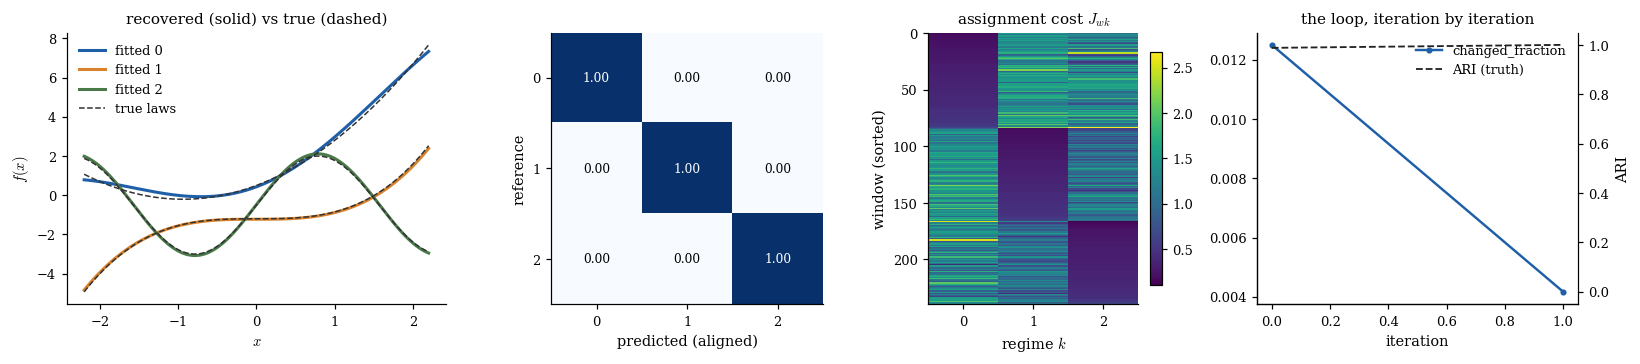

In [6]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.4), gridspec_kw={"width_ratios": [1.3, 1, 0.8, 1.1]})
viz.plot_laws(res.models, x_range=(-2.2, 2.2), truth=true_laws, ax=ax[0])
ax[0].set_title("recovered (solid) vs true (dashed)")
viz.plot_confusion(z, res.labels, ax=ax[1])
viz.plot_cost_matrix(res.total_cost, res.labels, ax=ax[2])
viz.plot_history(res.history, ax=ax[3], metrics=["changed_fraction"])
ax[3].set_title("the loop, iteration by iteration")
fig.tight_layout()

## 4 · Fit the soft EM

`SoftLRDSR` is the ordinary EM of the same mixture of library regressions:
every window gets a **posterior** over regimes rather than a hard label, and
the observed-data log-likelihood is a real, monotone learning curve.

{'ARI': 1.0, 'NMI': 1.0, 'aligned_accuracy': 1.0}  sigma per regime: [1.529 1.493 1.533]


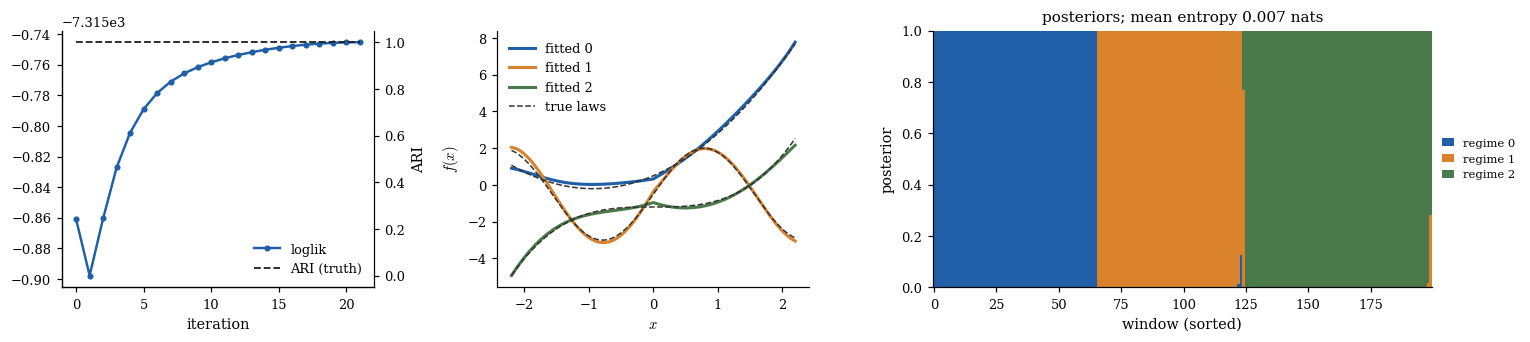

In [7]:
from lrdsr import SoftLRDSR

# started from a RANDOM partition, with deterministic annealing (T: 3 -> 1),
# so the learning curve has something to show
soft = SoftLRDSR(n_clusters=3, feature_names=["x"], init="random", temperature=3.0,
                 random_state=11).fit(X, y, true_labels_for_eval=z)
print(clustering_metrics(z, soft.labels), " sigma per regime:", soft.sigma.round(3))
fig, ax = plt.subplots(1, 3, figsize=(14, 3.2), gridspec_kw={"width_ratios": [1, 1, 1.6]})
viz.plot_history(soft.history, ax=ax[0], metrics=["loglik"])
viz.plot_laws(coef=soft.coef, feature_names=["x"], x_range=(-2.2, 2.2), truth=true_laws, ax=ax[1])
viz.plot_responsibilities(soft.responsibilities, ax=ax[2])
ax[2].set_title(f"posteriors; mean entropy {soft.entropy.mean():.3f} nats")
fig.tight_layout()

## 5 · Change the loss, or learn it

The equation term scores a window by a per-sample loss on its scaled
residual. `huber` is the default; any of `lrdsr.core.losses.LOSSES` can be
used, and `loss="learned"` refits a noise model (Gaussian / Laplace /
Student-t with fitted $\nu$) to the residuals every iteration, so the loss
is **learned** from the data. Here the noise is made heavy-tailed on purpose.

In [8]:
rng = np.random.default_rng(0)
clean = np.stack([true_laws[k](X[w, :, 0]) for w, k in enumerate(z)])
y_heavy = clean + 1.0 * rng.standard_t(2.0, size=y.shape)     # Student-t, nu = 2
rows = []
for loss in ("squared", "huber", "cauchy", "learned"):
    m = GroupedDCSR(n_clusters=3, alpha_geom=0.0, init="mechanism", loss=loss,
                    residual_scale="global", random_state=11)
    r = m.fit(X, y_heavy, Z, feature_names=["x"])
    rows.append({"loss": loss, **clustering_metrics(z, r.labels),
                 "learned": getattr(m, "learned_loss_", None) and
                            f"{m.learned_loss_.loss} {m.learned_loss_.params}"})
pd.DataFrame(rows)

,loss,ARI,NMI,aligned_accuracy,learned
0,squared,0.9006,0.8626,0.9667,NaN
1,huber,0.9879,0.9797,0.9958,NaN
2,cauchy,0.9879,0.9797,0.9958,NaN
3,learned,0.9756,0.9593,0.9917,student_t {'nu': 2.110985151154724}


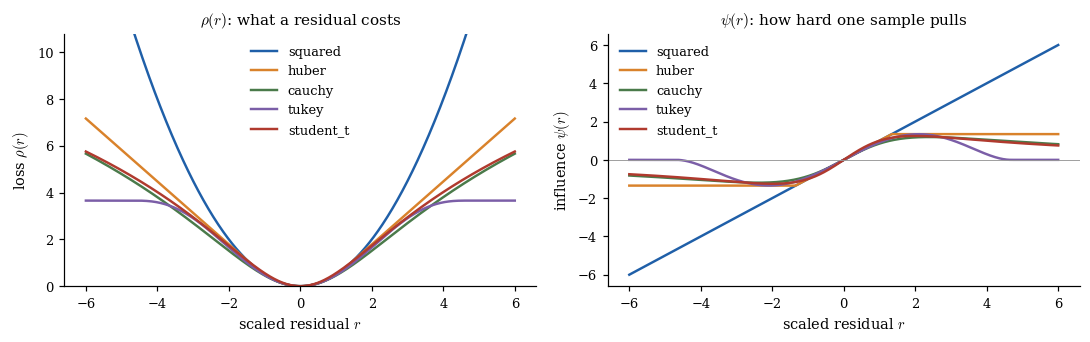

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
viz.plot_losses(ax=ax[0])
viz.plot_losses(ax=ax[1], influence=True)
ax[0].set_title(r"$\rho(r)$: what a residual costs")
ax[1].set_title(r"$\psi(r)$: how hard one sample pulls")
fig.tight_layout()

## Your own data

Everything above needs three arrays:

```python
X_seq  # (W, n, d)  the inputs of each window
y_seq  # (W, n)     the response
Z      # (W, p)     any window-level features (only the geometry term reads them;
       #            with alpha_geom=0 they can be anything, e.g. zeros)
```

Then `GroupedDCSR(n_clusters=K, alpha_geom=0, init="mechanism").fit(X_seq, y_seq, Z)`
for named laws, `SoftLRDSR(K).fit(X_seq, y_seq)` for posteriors, and
`OnlineLRDSR().warm_start(...)` to keep going in real time (notebook 04).